In [16]:
from google.colab import files
uploaded = files.upload()

import io
import pandas as pd

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])
  ))

  try:
    df_tix = pd.read_csv(io.BytesIO(uploaded[fn]))
    print("Successfully loaded CSV into df_tix")
  except pd.errors.ParseError:
    print(f"Error: Could not parse {fn} as a CSV. Please upload a valid CSV file.")
    df_tix = pd.DataFrame()
  except Exception as e:
    print(f"An unexpected error occured: {e}")
    df_tix = pd.DataFrame()

Saving tix_reviews_raw.csv to tix_reviews_raw (1).csv
User uploaded file "tix_reviews_raw (1).csv" with length 39818835 bytes
Successfully loaded CSV into df_tix


In [17]:
df_tix.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,ae6121ad-0a2f-4188-b4dd-e36990dc224e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,suka Membantu .. bisa cek smua teater film,5,0,4.5.0,2026-03-09 10:17:35,"Hi TIX Hunter, terima kasih atas ulasan yang A...",2026-03-09 11:16:27,4.5.0
1,790d3929-b2c0-44da-912e-277fce1a4f19,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,semoga kedepannya fitur Sinopsis film nya ada ...,3,3,4.4.0,2026-03-07 16:24:19,"Hi TIX Hunter, terima kasih atas review & sara...",2025-11-06 02:09:15,4.4.0
2,f046cc42-17aa-42bb-a0d4-27bf9807b390,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya tidak bisa login kembali lepas tu saya lu...,1,0,NaN,2026-03-06 04:53:40,"Hi TIX Hunter, mohon maaf atas ketidaknyamanan...",2026-03-06 05:03:19,NaN
3,e1c32907-e79f-4c70-877b-c77e905ab3da,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,keren,5,0,4.4.0,2026-02-28 04:51:50,"TIX Hunter, terima kasih atas ulasan yang Anda...",2026-02-28 05:09:05,4.4.0
4,3f7747d8-b446-4c83-bb1a-0448b70608ad,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,hemat waktu dan bisa pilih seat sesuka kita,5,0,4.4.0,2026-02-27 15:59:43,"TIX Hunter, terima kasih atas ulasan yang Anda...",2026-02-28 03:02:26,4.4.0


In [18]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

indonesian_stopwords = stopwords.words('indonesian')

print("Jumlah stopwords awal:", len(indonesian_stopwords))
print(indonesian_stopwords[:20])

Jumlah stopwords awal: 758
['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
text_column = 'content'

all_text = ' '.join(df_tix[text_column].dropna().astype(str))

In [20]:
from collections import Counter

words = all_text.split()

filtered_words = [
    word.lower()
    for word in words
    if word.lower() not in indonesian_stopwords
]

In [21]:
word_counts = Counter(filtered_words)

common_words = word_counts.most_common(100)

import pandas as pd

word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

display(word_freq_df)

,Word,Frequency
0,tiket,8889
1,good,8606
2,bagus,6971
3,aplikasi,5953
4,membantu,5794
...,...,...
95,coba,662
96,booking,660
97,deh,659
98,bayar,652


In [22]:
common_words

[('tiket', 8889),
 ('good', 8606),
 ('bagus', 6971),
 ('aplikasi', 5953),
 ('membantu', 5794),
 ('tix', 5248),
 ('promo', 4912),
 ('nya', 4796),
 ('ok', 4662),
 ('kode', 4510),
 ('mudah', 4240),
 ('mantap', 4202),
 ('ga', 4005),
 ('beli', 3865),
 ('gak', 3817),
 ('yg', 3753),
 ('id', 3686),
 ('voucher', 3567),
 ('nonton', 3134),
 ('antri', 2971),
 ('1', 2873),
 ('banget', 2794),
 ('suka', 2500),
 ('keren', 2442),
 ('pake', 2251),
 ('memudahkan', 2234),
 ('bioskop', 2143),
 ('ya', 1969),
 ('dana', 1893),
 ('diskon', 1886),
 ('udah', 1836),
 ('aja', 1753),
 ('nice', 1724),
 ('film', 1707),
 ('top', 1554),
 ('dapet', 1545),
 ('oke', 1539),
 ('kalo', 1532),
 ('update', 1470),
 ('tolong', 1417),
 ('promonya', 1416),
 ('mempermudah', 1389),
 ('pesan', 1346),
 ('mantul', 1341),
 ('get', 1325),
 ('cepat', 1302),
 ('buy', 1271),
 ('kasih', 1242),
 ('ribet', 1214),
 ('ngantri', 1202),
 ('aplikasinya', 1195),
 ('pas', 1187),
 ('gk', 1179),
 ('bgt', 1167),
 ('gampang', 1152),
 ('pakai', 1142),
 ('

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


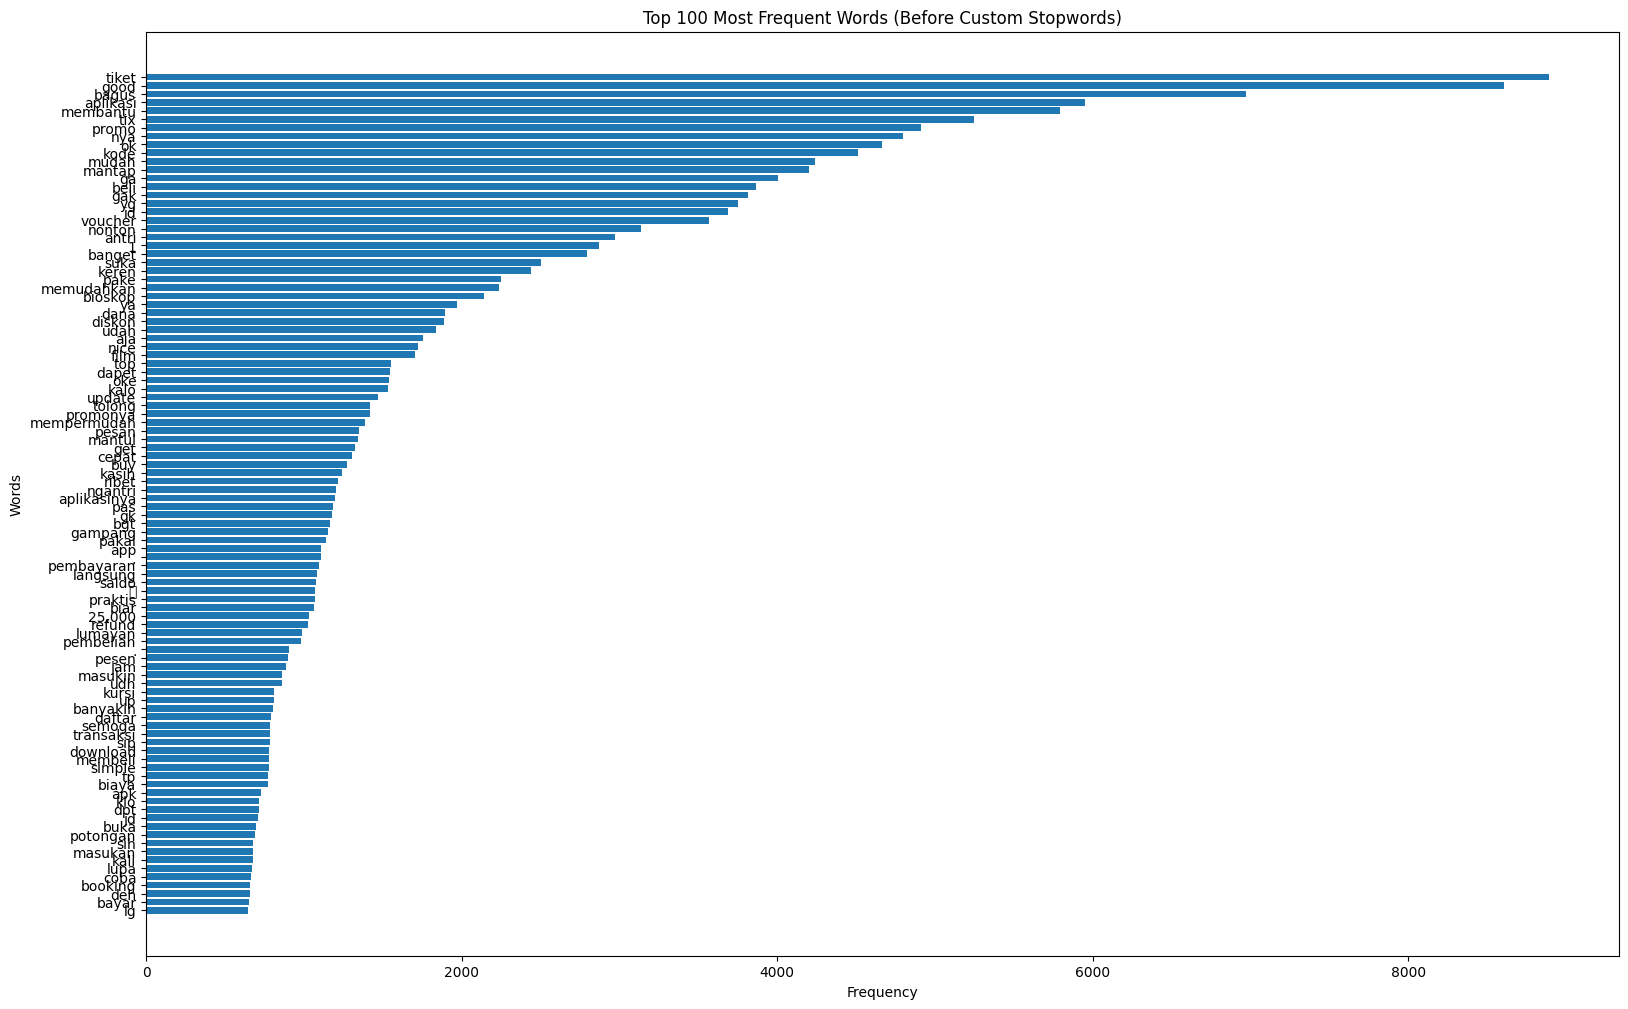

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(19,12))

plt.barh(
    word_freq_df['Word'][::-1],
    word_freq_df['Frequency'][::-1]
)

plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 100 Most Frequent Words (Before Custom Stopwords)")

plt.show()

In [24]:
custom_stopwords = [
    'ga','gak','yg','aja','nya','nih','dong','deh','sih',
    'banget','bgt','kayak','udah','kalo',
    'ya','ok','nice','top','get','buy','up','sip'
]

In [25]:
indonesian_stopwords_extended = set(indonesian_stopwords).union(custom_stopwords)

print("Jumlah stopwords baru:", len(indonesian_stopwords_extended))

Jumlah stopwords baru: 778


In [26]:
filtered_words_new = [
    word.lower()
    for word in words
    if word.lower() not in indonesian_stopwords_extended
]

In [27]:
word_counts_new = Counter(filtered_words_new)

common_words_new = word_counts_new.most_common(100)

word_freq_df_new = pd.DataFrame(common_words_new, columns=['Word', 'Frequency'])

display(word_freq_df_new)

,Word,Frequency
0,tiket,8889
1,good,8606
2,bagus,6971
3,aplikasi,5953
4,membantu,5794
...,...,...
95,tinggal,533
96,utk,524
97,kecewa,522
98,bikin,516


In [28]:
common_words_new

[('tiket', 8889),
 ('good', 8606),
 ('bagus', 6971),
 ('aplikasi', 5953),
 ('membantu', 5794),
 ('tix', 5248),
 ('promo', 4912),
 ('kode', 4510),
 ('mudah', 4240),
 ('mantap', 4202),
 ('beli', 3865),
 ('id', 3686),
 ('voucher', 3567),
 ('nonton', 3134),
 ('antri', 2971),
 ('1', 2873),
 ('suka', 2500),
 ('keren', 2442),
 ('pake', 2251),
 ('memudahkan', 2234),
 ('bioskop', 2143),
 ('dana', 1893),
 ('diskon', 1886),
 ('film', 1707),
 ('dapet', 1545),
 ('oke', 1539),
 ('update', 1470),
 ('tolong', 1417),
 ('promonya', 1416),
 ('mempermudah', 1389),
 ('pesan', 1346),
 ('mantul', 1341),
 ('cepat', 1302),
 ('kasih', 1242),
 ('ribet', 1214),
 ('ngantri', 1202),
 ('aplikasinya', 1195),
 ('pas', 1187),
 ('gk', 1179),
 ('gampang', 1152),
 ('pakai', 1142),
 ('app', 1107),
 (',', 1106),
 ('pembayaran', 1098),
 ('langsung', 1086),
 ('saldo', 1077),
 ('👍', 1072),
 ('praktis', 1071),
 ('biar', 1067),
 ('25.000', 1035),
 ('refund', 1024),
 ('lumayan', 991),
 ('pembelian', 983),
 ('.', 908),
 ('pesen', 

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


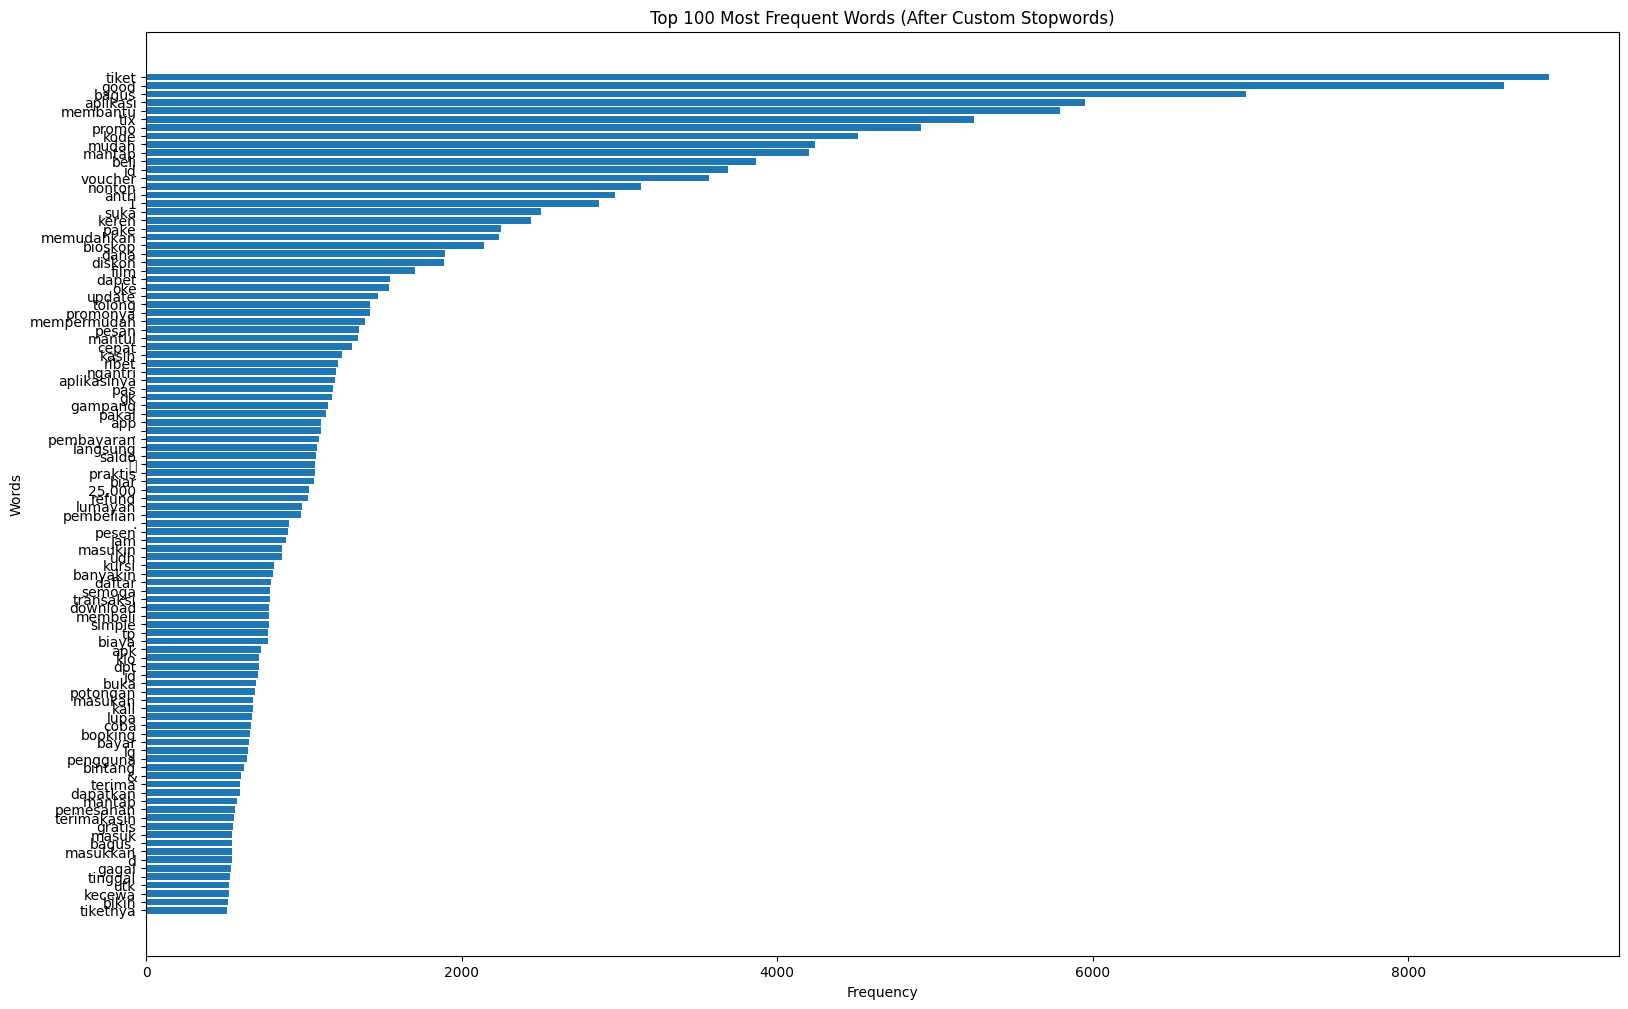

In [29]:
plt.figure(figsize=(19,12))

plt.barh(
    word_freq_df_new['Word'][::-1],
    word_freq_df_new['Frequency'][::-1]
)

plt.xlabel("Frequency")
plt.ylabel('Words')
plt.title("Top 100 Most Frequent Words (After Custom Stopwords)")

plt.show()